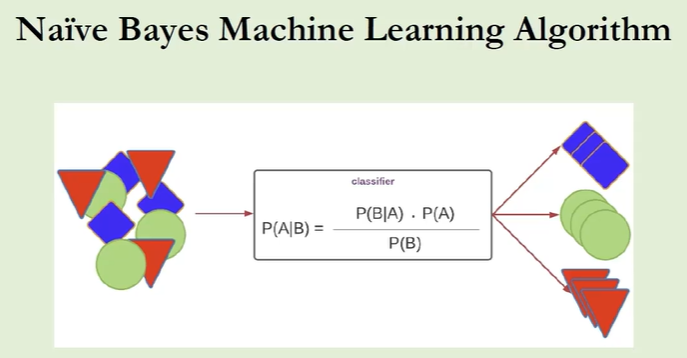

## What is Naive Bayes?

Naive Bayes is a probabilistic machine learning algorithm based on applying Bayes' Theorem with a strong (naive) assumption:

All input features are independent of each other given the class.

➔ Used primarily for classification tasks.

---

💡 **Real-World Intuition:**

Imagine you're a doctor diagnosing whether a patient has flu based on symptoms like fever, cough, and fatigue.

You'll check:

* How likely each symptom is if someone *has* the flu
* How likely those symptoms are if someone *doesn't* have flu

Then, you'll compare the probabilities to decide. That's Naive Bayes in real life!

---

🔶 **Bayes' Theorem**

Bayes' Theorem helps us reverse conditional probability:

$$P(A\vert{}B) = \frac{P(B\vert{}A) \cdot P(A)}{P(B)}$$

Where:

* $P(A\vert{}B)$ = Probability of A given B (posterior)
* $P(B\vert{}A)$ = Probability of B given A (likelihood)
* $P(A)$ = Prior probability of A
* $P(B)$ = Marginal probability of B

🔄 **Example:**

Let's say:

* $1\%$ of emails are spam $\rightarrow P(\text{Spam}) = 0.01$
* Word "lottery" appears in $90\%$ of spam emails $\rightarrow P(\text{"lottery"} \vert{} \text{Spam}) = 0.9$
* "Lottery" appears in $1\%$ of all emails $\rightarrow P(\text{"lottery"}) = 0.01$

Then:


$$P(\text{Spam}\vert{}\text{"lottery"}) = \frac{0.9 \cdot 0.01}{0.01} = 0.9$$

So, it's likely spam!


🔶 **Naive Bayes Assumption (Independence)**

Bayes' theorem gives us:

$$P(y\vert{}X) = \frac{P(X\vert{}y) \cdot P(y)}{P(X)}$$

Where:

* $P(y\vert{}X)$: Probability of class $y$ given features $X$ (what we want!)
* $P(X\vert{}y)$: Likelihood — probability of observing features $X$ if class is $y$
* $P(y)$: Prior — how common is class $y$
* $P(X)$: Probability of features $X$ (same for all classes, so we can ignore it when comparing classes)

---

💡 **2. Naive Assumption (Independence)**

Naive Bayes **assumes features are independent given the class**.
This simplifies:

$P(X\vert{}y) = P(x_1, x_2, \dots, x_n\vert{}y)$

To:

$P(X\vert{}y) = P(x_1\vert{}y) \cdot P(x_2\vert{}y) \cdot \dots \cdot P(x_n\vert{}y)$

This is what we wrote:

✅ 

$$P(X\vert{}y) = P(x_1\vert{}y) \times P(x_2\vert{}y) \times \dots \times P(x_n\vert{}y)$$

📊 **3. Final Naive Bayes Formula**

We combine everything:

$$P(y\vert{}X) \propto P(y) \cdot \prod_{i=1}^{n} P(x_i\vert{}y)$$

This means:

* Multiply the **prior** $P(y)$ by the **product of individual feature likelihoods** given class $y$

We compute this for **each class**, and choose the class with the **highest value**.

⚠️ The symbol "$\propto$" means "proportional to" — we don't divide by $P(X)$ because it's the same for all classes.

**Example:** we want to predict if a passenger survived on the Titanic, based on age, sex, and ticket class.

We use **Bayes' theorem** to compute the probability of each class (Survived or Not Survived) given the input features.

To simplify we **assume that each feature** (age, sex, class) **is independent**, which is not always true — but works surprisingly well in practice.

So instead of estimating one big joint probability, we just multiply small individual probabilities:

* ✅ What's the chance of this age, given survival?
* ✅ What's the chance of this sex, given survival?
* ✅ What's the chance of this class, given survival?

Multiply all those together and multiply by how common survival is overall. Do the same for non-survival.

Whichever class gives us the higher value — we predict that!

This makes it computationally efficient and scalable.

## Example Summary with Formula

To predict class:

$$P(y = 1 \vert{} X) \propto P(y = 1) \cdot P(x_1\vert{}y = 1) \cdot P(x_2\vert{}y = 1) \cdot \dots \cdot P(x_n\vert{}y = 1)$$

Compare it with:

$$P(y = 0 \vert{} X) \propto P(y = 0) \cdot P(x_1\vert{}y = 0) \cdot P(x_2\vert{}y = 0) \cdot \dots \cdot P(x_n\vert{}y = 0)$$

Pick the class with the higher result!

🎯 Scenario: Predict if a patient has Diabetes based on:

* Age
* Blood Pressure (BP)

Target variable: Diabetes $\rightarrow$ Yes / No

---

🧪 **Dataset**

| Patient | Age | BP | Diabetes |
| --- | --- | --- | --- |
| 1 | 25 | 80 | No |
| 2 | 35 | 70 | No |
| 3 | 45 | 85 | Yes |
| 4 | 50 | 90 | Yes |

Let's predict for a new patient:

* $\text{Age} = 42, \text{BP} = 82$

---

## 🧮 Step-by-Step Calculation:

We want to compute:


$$P(\text{Yes}\vert{}\text{Age}=42, \text{BP}=82) \quad \text{and} \quad P(\text{No}\vert{}\text{Age}=42, \text{BP}=82)$$

By **Bayes Theorem**:


$$P(y\vert{}X) \propto P(y) \times P(x_1\vert{}y) \times P(x_2\vert{}y)$$

Let's calculate for **each class** ($\text{Yes} / \text{No}$).

---

✅ **STEP 1: Priors**
Count of Yes: 2

Count of No: 2

Total: 4

$$P(\text{Yes}) = 2/4 = 0.5$$

$$P(\text{No}) = 2/4 = 0.5$$

---

✅ **STEP 2: Class-wise statistics**

For class = Yes

| Age | BP |
| --- | --- |
| 45 | 85 |
| 50 | 90 |

Mean & Std Dev:

* Age: mean = $(45+50)/2 = 47.5$, std $\approx 3.54$
* BP: mean = $(85+90)/2 = 87.5$, std $\approx 3.54$

$$s = \sqrt{\frac{\sum(x - \bar{x})^2}{n - 1}}$$

---

For class = No

| Age | BP |
| --- | --- |
| 25 | 80 |
| 35 | 70 |

Mean & Std Dev:

* Age: mean = $(25+35)/2 = 30$, std $\approx 7.07$

* BP: mean = $(80+70)/2 = 75$, std $\approx 7.07$

---

✅ **STEP 3: Likelihoods using Gaussian PDF (Probability Density Function)**

$$P(x\vert{}\mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \cdot e^{-\frac{(x - \mu)^2}{2\sigma^2}}$$

* 🔶 For class = Yes
* $P(\text{Age} = 42\vert{}\text{Yes})$

$$= \frac{1}{\sqrt{2\pi(3.54)^2}} \cdot e^{-\left((42-47.5)^2\right)/(2 \cdot 3.54^2)}$$

$$\approx 0.0370$$

* $P(\text{BP} = 82\vert{}\text{Yes})$

$$\approx 0.0486$$

Multiply with prior:

$$P(\text{Yes}\vert{}X) \propto 0.5 \cdot 0.0370 \cdot 0.0486 \approx 0.000899$$

* 🔶 For class = No
* $P(\text{Age} = 42\vert{}\text{No})$

$$= \frac{1}{\sqrt{2\pi(7.07)^2}} \cdot e^{-\left((42-30)^2\right)/(2 \cdot 7.07^2)}$$

$$\approx 0.0414$$

* $P(\text{BP} = 82\vert{}\text{No})$

$$\approx 0.0450$$

Multiply with prior:

$$P(\text{No}\vert{}X) \propto 0.5 \cdot 0.0414 \cdot 0.0450 \approx 0.000933$$

✅ **STEP 4: Final Prediction**

Compare:

* $P(\text{Yes}\vert{}X) \approx 0.000899$
* $P(\text{No}\vert{}X) \approx 0.000933$
* Here, $P(\text{No}\vert{}X) \approx 0.000933$ is higher than $P(\text{Yes}\vert{}X) \approx 0.000899$

**Hence:** Predicted: **No**

We calculated how likely this patient’s Age and BP values are under each class distribution, assuming features are independent.
Even with similar priors, the higher likelihood for 'No' made the final probability higher. So, Naive Bayes predicts **No**.

---

🔶 **Types of Naive Bayes**

| Type | Data Type | Example Use |
| --- | --- | --- |
| Gaussian NB | Continuous | Diabetes, Iris |
| Multinomial NB | Count-based | Text classification (word frequency) |
| Bernoulli NB | Binary | Spam detection (word present/not) |

🔶 **Why Is It Called "Naive"?**

Because we assume all features are independent from each other given the class. In real life, that's almost never true — but it still works well in many cases!

---

🔶 **Advantages and Limitations**

✅ **Advantages:**

* Simple, fast, easy to implement
* Works well for high-dimensional data (e.g., text)
* Doesn't require much training data

❌ **Limitations:**

* Assumes independence between features
* Continuous variables assumed to be Gaussian (in Gaussian NB)
* Can be outperformed by complex models when more training data is available

---

🌍 **Real-World Applications of Naive Bayes**

Naive Bayes is widely used in **industries and research**, especially when fast, interpretable, and scalable classification is needed.

💬 **1 Text Classification & NLP**

* **Spam detection**: Classify emails as spam or not (Multinomial/Bernoulli NB)
* **Sentiment analysis**: Determine whether a review is positive or negative
* **Language detection**: Identify the language of a given text
* **Topic categorization**: News or articles auto-tagged based on content

📌 **Example**: Gmail uses Naive Bayes in its early spam filters.

---

🧪 **2 Medical Diagnosis**

* Predict diseases (e.g., diabetes, cancer risk) based on test results
* Fast triage systems in hospitals

📌 Example: Pima Indians Diabetes dataset is often used with Gaussian Naive Bayes.

---

👨‍⚖️ **3 Legal and Forensic Tools**

* Authorship attribution in documents
* Predicting fraud or cybercrime intent based on behavior

---

🛍️ **4 Marketing & Recommendation**

* Customer classification: "Will buy" vs. "Won't buy"
* Email campaign categorization (interested / not interested)

### **4.Banking and Finance**
* Credit scoring: Classify customers as high or low credit risk
* Loan default prediction

---

🎓 **6 Education Tech**

* Student performance prediction
* Auto-grading short answers (basic NLP + NB)

---

**Bonus: Used as a Baseline**

Even in complex ML pipelines (like ensembles), Naive Bayes is often used as a **baseline** for benchmarking performance.